# Adhesion Comparison Analysis

Compares differential-adhesion (standard) vs flat-adhesion (noadhesion) simulations
to test whether NB-NB adhesion drives the spatial segregation seen in `norm_het_frac`.

**Primary question:** does removing differential adhesion push `norm_het_frac` toward 1.0
(random mixing)?

**Secondary question:** does removing differential adhesion affect composition metrics
(lineage area, NB count, pros count)?


---
## Section 0 — Setup


In [18]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


In [ ]:
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'pyproject.toml').exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError('Could not find repo root')
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / 'src'))
from npa.sim_viz import render_raw, load_raw_snapshot_full

SWEEP_ROOT  = REPO_ROOT / 'data/sim/sweep'
PROC_DIR    = REPO_ROOT / 'data/sim/processed_sweep'
FIGURES_DIR = PROC_DIR / 'figures/analysis'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sim     = pd.read_csv(PROC_DIR / 'sim_metrics_last.csv')
run_idx = pd.read_csv(PROC_DIR / 'sim_run_index.csv', dtype=str)
run_idx['npz_row'] = run_idx['npz_row'].astype(int)

print('sim_metrics_last:', len(sim), 'rows')
print('Conditions found:', sorted(sim['condition'].unique()))
print('sim_ids found:   ', sorted(sim['sim_id'].unique()))

In [ ]:
import re as _re

# ── Sim-series metadata (adjust if your new simulations use different IDs) ──
SIM_ID_META = {
    'sim41': {'regulatory_dynamic': 'NONE',    'critical_volume_mode': 1, 'genotype': 'mudmut'},
    'sim42': {'regulatory_dynamic': 'NB-ABM',  'critical_volume_mode': 1, 'genotype': 'mudmut'},
    'sim43': {'regulatory_dynamic': 'VOL-ABM', 'critical_volume_mode': 1, 'genotype': 'mudmut'},
    'sim44': {'regulatory_dynamic': 'NB-PDE',  'critical_volume_mode': 1, 'genotype': 'mudmut'},
    'sim45': {'regulatory_dynamic': 'VOL-PDE', 'critical_volume_mode': 1, 'genotype': 'mudmut'},
    'sim51': {'regulatory_dynamic': 'NONE',    'critical_volume_mode': 0, 'genotype': 'mudmut'},
    'sim52': {'regulatory_dynamic': 'NB-ABM',  'critical_volume_mode': 0, 'genotype': 'mudmut'},
    'sim53': {'regulatory_dynamic': 'VOL-ABM', 'critical_volume_mode': 0, 'genotype': 'mudmut'},
    'sim54': {'regulatory_dynamic': 'NB-PDE',  'critical_volume_mode': 0, 'genotype': 'mudmut'},
    'sim55': {'regulatory_dynamic': 'VOL-PDE', 'critical_volume_mode': 0, 'genotype': 'mudmut'},
    'sim61': {'regulatory_dynamic': 'NONE',    'critical_volume_mode': 1, 'genotype': 'wt'},
    'sim62': {'regulatory_dynamic': 'NB-ABM',  'critical_volume_mode': 1, 'genotype': 'wt'},
    'sim63': {'regulatory_dynamic': 'VOL-ABM', 'critical_volume_mode': 1, 'genotype': 'wt'},
    'sim64': {'regulatory_dynamic': 'NB-PDE',  'critical_volume_mode': 1, 'genotype': 'wt'},
    'sim65': {'regulatory_dynamic': 'VOL-PDE', 'critical_volume_mode': 1, 'genotype': 'wt'},
    'sim71': {'regulatory_dynamic': 'NONE',    'critical_volume_mode': 0, 'genotype': 'wt'},
    'sim72': {'regulatory_dynamic': 'NB-ABM',  'critical_volume_mode': 0, 'genotype': 'wt'},
    'sim73': {'regulatory_dynamic': 'VOL-ABM', 'critical_volume_mode': 0, 'genotype': 'wt'},
    'sim74': {'regulatory_dynamic': 'NB-PDE',  'critical_volume_mode': 0, 'genotype': 'wt'},
    'sim75': {'regulatory_dynamic': 'VOL-PDE', 'critical_volume_mode': 0, 'genotype': 'wt'},
}

# Attach regulatory_dynamic, critical_volume_mode, genotype via sim_id
_meta_df = pd.DataFrame(SIM_ID_META).T.reset_index().rename(columns={'index': 'sim_id'})
_meta_df['critical_volume_mode'] = _meta_df['critical_volume_mode'].astype(int)
sim = sim.drop(columns=[c for c in ['regulatory_dynamic', 'critical_volume_mode', 'genotype']
                         if c in sim.columns], errors='ignore')
sim = sim.merge(_meta_df, on='sim_id', how='left')

# ── Condition pairs: base (differential adhesion) vs noadhesion ──────────
# noadhesion=None means no flat-adhesion control was run for that condition.
# All WT conditions are differential-adhesion only (no noadhesion runs).
MM_PAIRS = [
    # divMean=0
    {'tag': 'D0S26_R0S0',    'base': 'mudmut_divMean0Stdev26_rotMean0Stdev0',
     'noadhesion': 'mudmut_divMean0Stdev26_rotMean0Stdev0_noadhesion'},
    {'tag': 'D0S26_R0S30',   'base': 'mudmut_divMean0Stdev26_rotMean0Stdev30',
     'noadhesion': 'mudmut_divMean0Stdev26_rotMean0Stdev30_noadhesion'},
    {'tag': 'D0S26_R11S30',  'base': 'mudmut_divMean0Stdev26_rotMean11Stdev30',
     'noadhesion': 'mudmut_divMean0Stdev26_rotMean11Stdev30_noadhesion'},
    {'tag': 'D0S26_R45S30',  'base': 'mudmut_divMean0Stdev26_rotMean45Stdev30',
     'noadhesion': 'mudmut_divMean0Stdev26_rotMean45Stdev30_noadhesion'},
    {'tag': 'D0S26_R90S30',  'base': 'mudmut_divMean0Stdev26_rotMean90Stdev30',
     'noadhesion': 'mudmut_divMean0Stdev26_rotMean90Stdev30_noadhesion'},
    # divMean=11
    {'tag': 'D11S26_R0S0',   'base': 'mudmut_divMean11Stdev26_rotMean0Stdev0',
     'noadhesion': 'mudmut_divMean11Stdev26_rotMean0Stdev0_noadhesion'},
    {'tag': 'D11S26_R0S30',  'base': 'mudmut_divMean11Stdev26_rotMean0Stdev30',
     'noadhesion': 'mudmut_divMean11Stdev26_rotMean0Stdev30_noadhesion'},
    {'tag': 'D11S26_R11S30', 'base': 'mudmut_divMean11Stdev26_rotMean11Stdev30',
     'noadhesion': 'mudmut_divMean11Stdev26_rotMean11Stdev30_noadhesion'},
    # divMean=45
    {'tag': 'D45S26_R0S30',  'base': 'mudmut_divMean45Stdev26_rotMean0Stdev30',
     'noadhesion': 'mudmut_divMean45Stdev26_rotMean0Stdev30_noadhesion'},
    {'tag': 'D45S26_R45S30', 'base': 'mudmut_divMean45Stdev26_rotMean45Stdev30',
     'noadhesion': 'mudmut_divMean45Stdev26_rotMean45Stdev30_noadhesion'},
    # divMean=90
    {'tag': 'D90S26_R0S30',  'base': 'mudmut_divMean90Stdev26_rotMean0Stdev30',
     'noadhesion': 'mudmut_divMean90Stdev26_rotMean0Stdev30_noadhesion'},
    {'tag': 'D90S26_R45S30', 'base': 'mudmut_divMean90Stdev26_rotMean45Stdev30',
     'noadhesion': 'mudmut_divMean90Stdev26_rotMean45Stdev30_noadhesion'},
]
WT_PAIRS = [
    {'tag': 'D0S26',  'base': 'wt_divMean0Stdev26',  'noadhesion': None},
    {'tag': 'D11S26', 'base': 'wt_divMean11Stdev26', 'noadhesion': None},
    {'tag': 'D45S26', 'base': 'wt_divMean45Stdev26', 'noadhesion': None},
    {'tag': 'D90S26', 'base': 'wt_divMean90Stdev26', 'noadhesion': None},
]
ALL_PAIRS = MM_PAIRS + WT_PAIRS

# Flat lookup: condition_name → (tag, adhesion_type)
COND_INFO = {}
for p in ALL_PAIRS:
    COND_INFO[p['base']] = {'tag': p['tag'], 'adhesion': 'differential'}
    if p['noadhesion'] is not None:
        COND_INFO[p['noadhesion']] = {'tag': p['tag'], 'adhesion': 'flat'}

sim['tag']      = sim['condition'].map(lambda c: COND_INFO.get(c, {}).get('tag', c))
sim['adhesion'] = sim['condition'].map(lambda c: COND_INFO.get(c, {}).get('adhesion', 'unknown'))

# ── div_mean helpers for faceted charts ──────────────────────────────────
DIV_MEAN_ORDER = [0, 11, 45, 90]

def _extract_div_mean(tag: str) -> int:
    """Extract the integer divMean from a tag string like 'D45S26_R0S30' → 45."""
    m = _re.search(r'D(\d+)', tag)
    return int(m.group(1)) if m else -1

def _rot_label(tag: str) -> str:
    """Short label showing only the rotation part, e.g. 'D0S26_R0S30' → 'R0S30'."""
    m = _re.search(r'(R\d+S\d+)', tag)
    return m.group(1) if m else tag

sim['div_mean'] = sim['tag'].map(_extract_div_mean)

# Group MM_PAIRS by div_mean for faceted charts
MM_BY_DIVMEAN = {dm: [p for p in MM_PAIRS if _extract_div_mean(p['tag']) == dm]
                 for dm in DIV_MEAN_ORDER}

# Verify all expected conditions are present
present = set(sim['condition'].unique())
for p in ALL_PAIRS:
    flag = '✓' if p['base'] in present else '✗ MISSING'
    print(f"{flag}  {p['base']}")
    if p['noadhesion'] is not None:
        flag = '✓' if p['noadhesion'] in present else '✗ MISSING'
        print(f"{flag}  {p['noadhesion']}")
    else:
        print(f"—  (no noadhesion for {p['tag']})")

In [ ]:
import npa.sim_viz as _sim_viz_mod

# Patch module-level color constants so render_raw picks them up even after a prior import
_sim_viz_mod.POP2_COLOR = '#4a96b7'   # GMC
_sim_viz_mod.POP3_COLOR = '#00a6a4'   # Neuron

NB_COLOR   = _sim_viz_mod.NB_COLOR
POP2_COLOR = _sim_viz_mod.POP2_COLOR
POP3_COLOR = _sim_viz_mod.POP3_COLOR

REG_DYN_ORDER  = ['NONE', 'NB-ABM', 'VOL-ABM', 'NB-PDE', 'VOL-PDE']
REG_DYN_COLORS = {
    'NONE':    '#888888',
    'NB-ABM':  '#4e9ed4',
    'VOL-ABM': '#5ab454',
    'NB-PDE':  '#e87b39',
    'VOL-PDE': '#d84444',
}
METRICS = ['lin_area_vox', 'n_pros', 'n_dpn', 'dpn_area_vox', 'avg_dpn_area_vox']
METRIC_LABELS = {
    'lin_area_vox':     'Lineage area (vox)',
    'n_pros':           'Pros count',
    'n_dpn':            'NB count',
    'dpn_area_vox':     'Total NB area (vox)',
    'avg_dpn_area_vox': 'Avg NB area (vox/cell)',
}


def heterotypic_contact_fraction(geo):
    nb    = geo[..., 0] > 0
    nonnb = geo[..., 1] > 0
    occ   = nb | nonnb
    n_occ = int(occ.sum())
    if n_occ == 0:
        return dict(het_frac=np.nan, norm_het_frac=np.nan,
                    p_nb=np.nan, p_nonnb=np.nan, n_occupied=0)
    p_nb_val    = float(nb[occ].mean())
    p_nonnb_val = float(nonnb[occ].mean())
    both_h = occ[:, :-1] & occ[:, 1:]
    het_h  = both_h & (nb[:, :-1] ^ nb[:, 1:])
    both_v = occ[:-1, :] & occ[1:, :]
    het_v  = both_v & (nb[:-1, :] ^ nb[1:, :])
    total = int(both_h.sum()) + int(both_v.sum())
    het   = int(het_h.sum())  + int(het_v.sum())
    if total == 0:
        return dict(het_frac=np.nan, norm_het_frac=np.nan,
                    p_nb=p_nb_val, p_nonnb=p_nonnb_val, n_occupied=n_occ)
    hf       = het / total
    expected = 2.0 * p_nb_val * p_nonnb_val
    norm_hf  = (hf / expected) if expected > 0 else np.nan
    return dict(het_frac=hf, norm_het_frac=norm_hf,
                p_nb=p_nb_val, p_nonnb=p_nonnb_val, n_occupied=n_occ)


def nb_exposure_fraction(geo):
    """
    Fraction of the NB region's perimeter exposed to extracellular space.

    Perimeter = all 4-connected edges between an NB pixel and a non-NB pixel.
    Each such edge is classified as:
      exposed : the non-NB neighbor is empty (neither NB nor any other cell type)
      contact : the non-NB neighbor is occupied by any other cell type

    NB-NB pixel adjacencies are interior and not counted.
    """
    nb    = geo[..., 0] > 0
    nonnb = geo[..., 1] > 0
    emp   = ~(nb | nonnb)

    n_exposed = 0
    n_contact = 0

    # Right: NB at (i,j), non-NB neighbor at (i,j+1)
    e = nb[:, :-1] & ~nb[:, 1:]
    n_exposed += int((e & emp[:, 1:]).sum())
    n_contact += int((e & nonnb[:, 1:]).sum())

    # Left: NB at (i,j+1), non-NB neighbor at (i,j)
    e = nb[:, 1:] & ~nb[:, :-1]
    n_exposed += int((e & emp[:, :-1]).sum())
    n_contact += int((e & nonnb[:, :-1]).sum())

    # Down: NB at (i,j), non-NB neighbor at (i+1,j)
    e = nb[:-1, :] & ~nb[1:, :]
    n_exposed += int((e & emp[1:, :]).sum())
    n_contact += int((e & nonnb[1:, :]).sum())

    # Up: NB at (i+1,j), non-NB neighbor at (i,j)
    e = nb[1:, :] & ~nb[:-1, :]
    n_exposed += int((e & emp[:-1, :]).sum())
    n_contact += int((e & nonnb[:-1, :]).sum())

    n_perimeter = n_exposed + n_contact
    if n_perimeter == 0:
        return dict(exposed_frac=np.nan, n_exposed=0, n_contact=0, n_perimeter=0)
    return dict(
        exposed_frac = n_exposed / n_perimeter,
        n_exposed    = n_exposed,
        n_contact    = n_contact,
        n_perimeter  = n_perimeter,
    )


def draw_example_lineage(condition, sim_id, run_id=None, title='', ax=None):
    """Render a lineage using raw CELLS/LOCATIONS JSON: NB=purple, GMC=blue, Neuron=teal."""
    subset = sim[(sim['condition'] == condition) & (sim['sim_id'] == sim_id)]
    if subset.empty:
        raise ValueError(f'No rows for condition={condition}, sim_id={sim_id}')
    if run_id is None:
        mean_val = subset['lin_area_vox'].mean()
        run_id = str(subset.loc[
            (subset['lin_area_vox'] - mean_val).abs().idxmin(), 'run_id'
        ]).zfill(4)
    run_id = str(run_id).zfill(4)
    match = run_idx[
        (run_idx['condition'] == condition) &
        (run_idx['sim_id']    == sim_id) &
        (run_idx['run_id']    == run_id)
    ]
    if match.empty:
        raise ValueError(f'run_index missing: {condition} {sim_id} {run_id}')
    r = match.iloc[0]
    geo_raw, lmap = load_raw_snapshot_full(
        REPO_ROOT / r['cells_path'],
        REPO_ROOT / r['locs_path'],
    )
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    render_raw(geo_raw, label_map=lmap, ax=ax, title=title)
    ax.axis('off')
    return ax

---
## Section 1 — Heterotypic Contact Fraction

Computes `norm_het_frac` for every run in both adhesion conditions and compares
within each (tag, VCV, regulatory dynamic) group.

**Expectation if differential adhesion drives segregation:**
- `norm_het_frac` (differential) ≈ 0.03–0.05 (strongly segregated)
- `norm_het_frac` (flat)         >> 0.05, approaching 1.0 (random mixing)


In [23]:
_HET_CSV = PROC_DIR / 'het_contact_metrics.csv'

if _HET_CSV.exists():
    het_df = pd.read_csv(_HET_CSV)
    print(f'Loaded cached het_contact_metrics.csv ({len(het_df)} rows)')
else:
    het_records = []
    for npz_path_str, group in run_idx.groupby('npz_path'):
        with np.load(REPO_ROOT / npz_path_str) as _d:
            _geo_all = _d['geo']
        for _, row in group.iterrows():
            result = heterotypic_contact_fraction(_geo_all[int(row['npz_row'])])
            het_records.append({
                'condition': row['condition'],
                'sim_id':    row['sim_id'],
                'run_id':    row['run_id'],
                **result,
            })
    het_df = pd.DataFrame(het_records)

    # attach metadata
    _meta = sim[['condition','sim_id','regulatory_dynamic',
                  'critical_volume_mode','genotype','tag','adhesion']].drop_duplicates()
    het_df = het_df.merge(_meta, on=['condition','sim_id'], how='left')
    het_df.to_csv(_HET_CSV, index=False)
    print(f'Computed and saved ({len(het_df)} rows)')

# Ensure metadata columns present if loaded from cache
if 'adhesion' not in het_df.columns:
    _meta = sim[['condition','sim_id','regulatory_dynamic',
                  'critical_volume_mode','genotype','tag','adhesion']].drop_duplicates()
    het_df = het_df.merge(_meta, on=['condition','sim_id'], how='left')

# Derive div_mean from tag (handles cached CSVs that pre-date this column)
if 'div_mean' not in het_df.columns:
    het_df['div_mean'] = het_df['tag'].map(_extract_div_mean)

print()
print(het_df.groupby(['genotype','tag','adhesion'])['norm_het_frac']
      .agg(['mean','std','median']).round(4).to_string())

Loaded cached het_contact_metrics.csv (12000 rows)

                                       mean     std  median
genotype tag           adhesion                            
mudmut   D0S26_R0S0    differential  0.0360  0.0208  0.0282
                       flat          0.0380  0.0232  0.0293
         D0S26_R0S30   differential  0.0392  0.0221  0.0320
                       flat          0.0405  0.0236  0.0324
         D0S26_R11S30  differential  0.0401  0.0223  0.0324
                       flat          0.0415  0.0239  0.0334
         D11S26_R0S0   differential  0.0365  0.0220  0.0280
                       flat          0.0378  0.0237  0.0282
         D11S26_R0S30  differential  0.0393  0.0227  0.0314
                       flat          0.0402  0.0243  0.0312
         D11S26_R11S30 differential  0.0403  0.0230  0.0319
                       flat          0.0411  0.0248  0.0316
         D45S26_R0S30  differential  0.0433  0.0242  0.0342
                       flat          0.0447  0.0

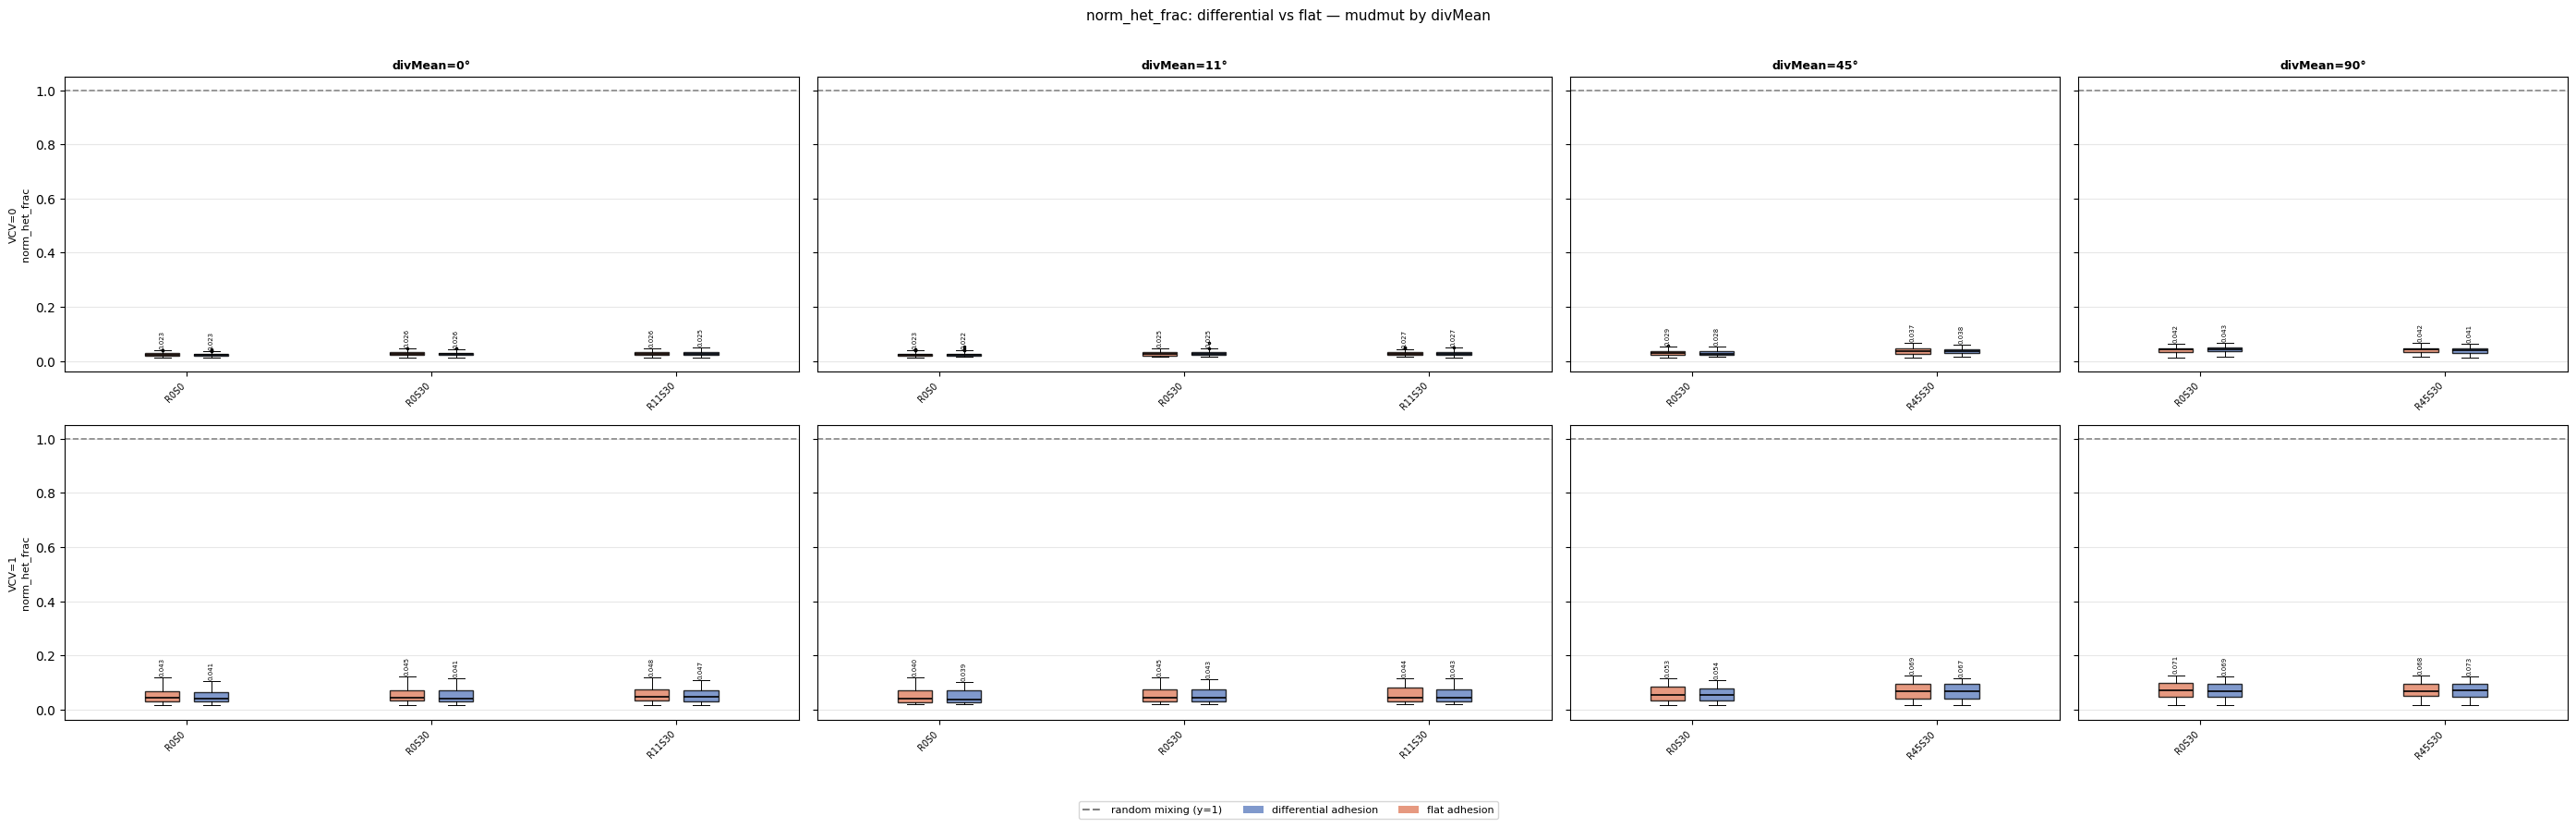

In [24]:
# Primary chart: norm_het_frac differential vs flat, faceted by divMean (columns) × VCV (rows)
# X-axis within each panel = rotation conditions; WT has no flat control so omitted here.
ADH_COLORS = {'flat': '#e08060', 'differential': '#6080c0'}
box_w   = 0.14
offsets = np.array([-0.10, 0.10])   # flat left, differential right

vcv_modes = sorted(het_df['critical_volume_mode'].dropna().unique().astype(int))
n_vcv = len(vcv_modes)

_width_ratios = [max(1, len(MM_BY_DIVMEAN.get(dm, []))) for dm in DIV_MEAN_ORDER]
_total_tags   = sum(_width_ratios)

fig, axes = plt.subplots(
    n_vcv, len(DIV_MEAN_ORDER),
    figsize=(2.8 * _total_tags, 4.5 * n_vcv),
    sharey=True, squeeze=False,
    gridspec_kw={'width_ratios': _width_ratios},
)

for ri, vcv in enumerate(vcv_modes):
    sub = het_df[
        (het_df['genotype'] == 'mudmut') &
        (het_df['critical_volume_mode'] == vcv)
    ].dropna(subset=['norm_het_frac'])

    for ci, dm in enumerate(DIV_MEAN_ORDER):
        ax = axes[ri, ci]
        ax.axhline(1.0, color='gray', linestyle='--', linewidth=1.2, zorder=1)

        dm_pairs = MM_BY_DIVMEAN.get(dm, [])
        n = len(dm_pairs)

        for ti, p in enumerate(dm_pairs):
            tag = p['tag']
            for ai, adh in enumerate(['flat', 'differential']):
                if adh == 'flat' and p['noadhesion'] is None:
                    continue
                runs = sub[(sub['tag'] == tag) & (sub['adhesion'] == adh)]['norm_het_frac']
                if runs.empty:
                    continue
                x  = ti + offsets[ai]
                bp = ax.boxplot(
                    [runs], positions=[x], widths=box_w,
                    patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 1.2},
                    whiskerprops={'linewidth': 0.7},
                    capprops={'linewidth': 0.7},
                    flierprops={'marker': 'o', 'markersize': 1.5, 'linestyle': 'none'},
                    manage_ticks=False, zorder=2,
                )
                bp['boxes'][0].set_facecolor(ADH_COLORS[adh])
                bp['boxes'][0].set_alpha(0.8)
                med       = float(np.median(runs))
                upper_cap = bp['caps'][1].get_ydata()[0]
                ax.text(x, upper_cap + 0.005, f'{med:.3f}',
                        ha='center', va='bottom', fontsize=5, rotation=90)

        ax.set_xlim(-0.5, n - 0.5)
        ax.set_xticks(list(range(n)))
        ax.set_xticklabels([_rot_label(p['tag']) for p in dm_pairs],
                           rotation=45, ha='right', fontsize=7)
        ax.grid(axis='y', alpha=0.3)

        if ri == 0:
            ax.set_title(f'divMean={dm}°', fontsize=9, fontweight='bold')
        if ci == 0:
            ax.set_ylabel(f'VCV={vcv}\nnorm_het_frac', fontsize=8)

legend_handles = [
    Line2D([0], [0], color='gray', linestyle='--', label='random mixing (y=1)'),
    Patch(facecolor=ADH_COLORS['differential'], alpha=0.8, label='differential adhesion'),
    Patch(facecolor=ADH_COLORS['flat'],          alpha=0.8, label='flat adhesion'),
]
fig.suptitle('norm_het_frac: differential vs flat — mudmut by divMean', fontsize=11)
fig.legend(handles=legend_handles, fontsize=8, loc='lower center',
           ncol=3, bbox_to_anchor=(0.5, 0.0))
fig.tight_layout(rect=[0, 0.06, 1, 0.97])
fig.savefig(FIGURES_DIR / 'het_adhesion_by_divmean_mudmut.png', dpi=120, bbox_inches='tight')
plt.show()

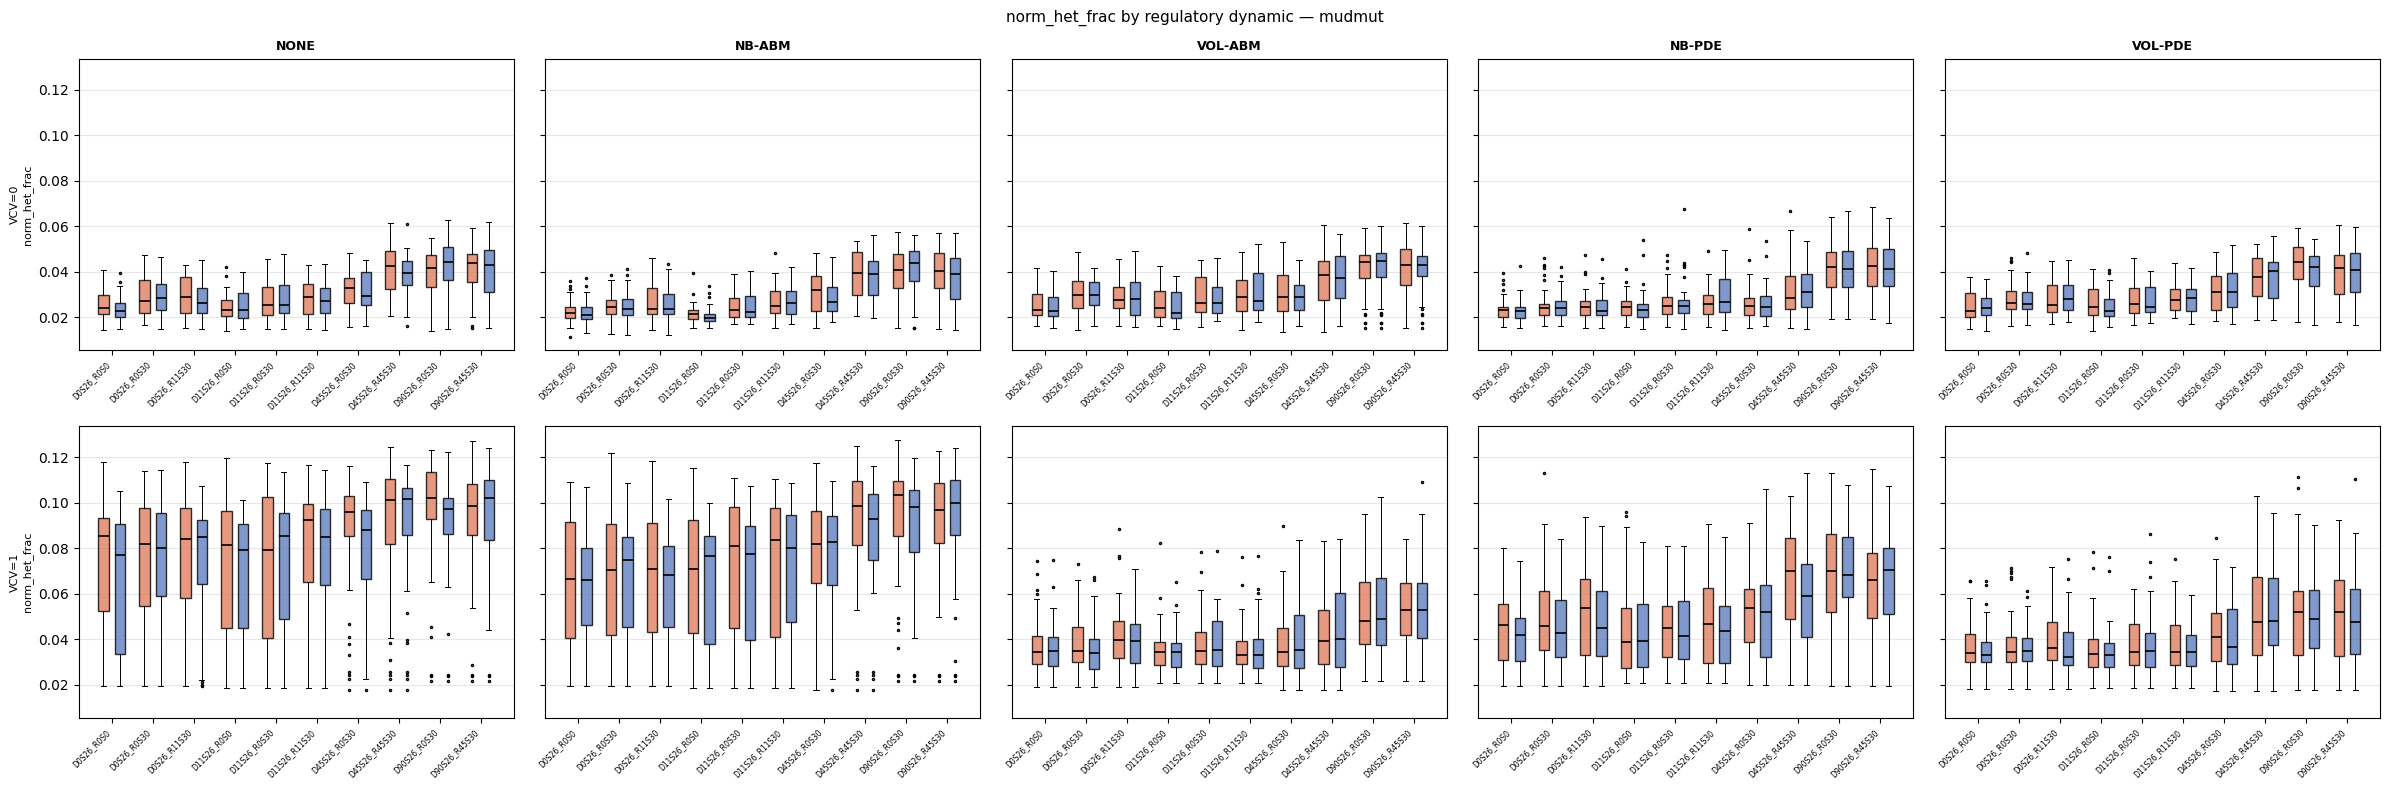

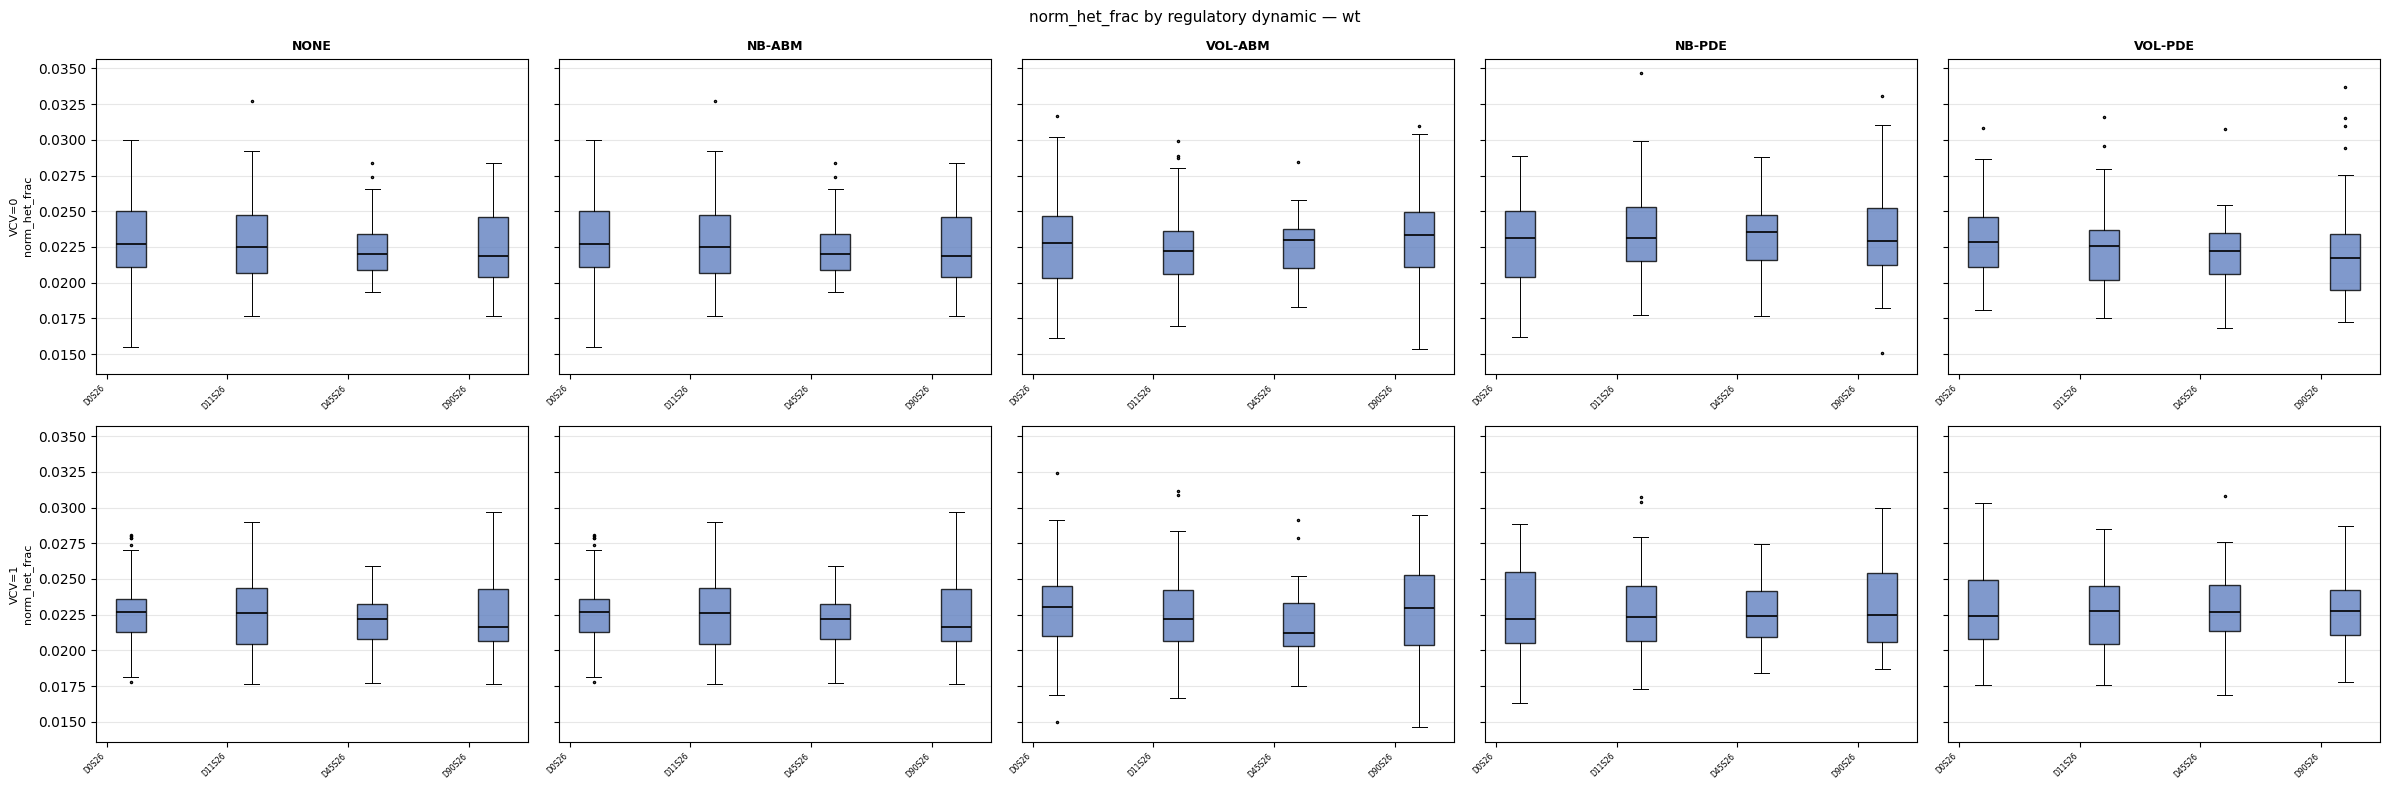

In [28]:
# Secondary chart: break down by regulatory dynamic to check consistency
for genotype, pairs in [('mudmut', MM_PAIRS), ('wt', WT_PAIRS)]:
    tags     = [p['tag'] for p in pairs]
    n_tags   = len(tags)
    positions = list(range(n_tags))

    vcv_modes = sorted(het_df['critical_volume_mode'].dropna().unique().astype(int))
    fig, axes = plt.subplots(
        len(vcv_modes), len(REG_DYN_ORDER),
        figsize=(24, 4 * len(vcv_modes)), sharey=True
    )
    if axes.ndim == 1:
        axes = axes.reshape(1, -1)

    ADH_COLORS = {'flat': '#e08060', 'differential': '#6080c0'}

    for ri, vcv in enumerate(vcv_modes):
        for ci, reg_dyn in enumerate(REG_DYN_ORDER):
            ax = axes[ri, ci]
            #ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, zorder=1)

            panel = het_df[
                (het_df['genotype'] == genotype) &
                (het_df['critical_volume_mode'] == vcv) &
                (het_df['regulatory_dynamic']   == reg_dyn)
            ].dropna(subset=['norm_het_frac'])

            data_flat = [panel[(panel['tag']==t)&(panel['adhesion']=='flat')]['norm_het_frac']
                         for t in tags]
            data_diff = [panel[(panel['tag']==t)&(panel['adhesion']=='differential')]['norm_het_frac']
                         for t in tags]

            if all(d.empty for d in data_flat + data_diff):
                ax.set_visible(False)
                continue

            offsets = np.array([-0.2, 0.2])
            for ai, (data, adh) in enumerate([(data_flat,'flat'),(data_diff,'differential')]):
                vals = [d.values if not d.empty else np.array([np.nan]) for d in data]
                bp = ax.boxplot(
                    vals,
                    positions=[p + offsets[ai] for p in positions],
                    widths=0.25,
                    patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 1.2},
                    whiskerprops={'linewidth': 0.7},
                    capprops={'linewidth': 0.7},
                    flierprops={'marker': 'o', 'markersize': 1.5, 'linestyle': 'none'},
                    manage_ticks=False, zorder=2,
                )
                for patch in bp['boxes']:
                    patch.set_facecolor(ADH_COLORS[adh])
                    patch.set_alpha(0.8)

            ax.set_xticks(positions)
            ax.set_xticklabels(tags, rotation=45, ha='right', fontsize=5.5)
            ax.grid(axis='y', alpha=0.3)
            if ri == 0:
                ax.set_title(reg_dyn, fontsize=9, fontweight='bold')
            if ci == 0:
                ax.set_ylabel(f'VCV={vcv}\nnorm_het_frac', fontsize=8)

    fig.suptitle(f'norm_het_frac by regulatory dynamic — {genotype}', fontsize=11)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f'het_adhesion_by_regdyn_{genotype}.png',
                dpi=120, bbox_inches='tight')
    plt.show()


In [29]:
MM_PAIRS

[{'tag': 'D0S26_R0S0',
  'base': 'mudmut_divMean0Stdev26_rotMean0Stdev0',
  'noadhesion': 'mudmut_divMean0Stdev26_rotMean0Stdev0_noadhesion'},
 {'tag': 'D0S26_R0S30',
  'base': 'mudmut_divMean0Stdev26_rotMean0Stdev30',
  'noadhesion': 'mudmut_divMean0Stdev26_rotMean0Stdev30_noadhesion'},
 {'tag': 'D0S26_R11S30',
  'base': 'mudmut_divMean0Stdev26_rotMean11Stdev30',
  'noadhesion': 'mudmut_divMean0Stdev26_rotMean11Stdev30_noadhesion'},
 {'tag': 'D11S26_R0S0',
  'base': 'mudmut_divMean11Stdev26_rotMean0Stdev0',
  'noadhesion': 'mudmut_divMean11Stdev26_rotMean0Stdev0_noadhesion'},
 {'tag': 'D11S26_R0S30',
  'base': 'mudmut_divMean11Stdev26_rotMean0Stdev30',
  'noadhesion': 'mudmut_divMean11Stdev26_rotMean0Stdev30_noadhesion'},
 {'tag': 'D11S26_R11S30',
  'base': 'mudmut_divMean11Stdev26_rotMean11Stdev30',
  'noadhesion': 'mudmut_divMean11Stdev26_rotMean11Stdev30_noadhesion'},
 {'tag': 'D45S26_R0S30',
  'base': 'mudmut_divMean45Stdev26_rotMean0Stdev30',
  'noadhesion': 'mudmut_divMean45Stde

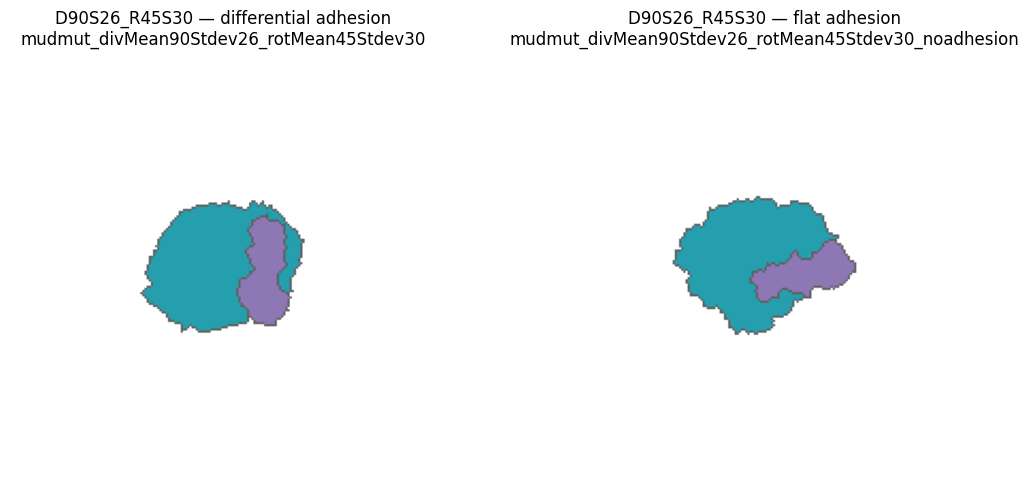

In [35]:
# Example lineages: one differential vs one flat for the same tag/sim
# Pick the first available mudmut condition and sim41 (NONE, VCV=1)
_pair   = MM_PAIRS[9]
_sim_id = 'sim43'

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, key, label in [
    (axes[0], 'base',        'differential adhesion'),
    (axes[1], 'noadhesion',  'flat adhesion'),
]:
    draw_example_lineage(
        condition=_pair[key],
        sim_id=_sim_id,
        title=f"{_pair['tag']} — {label}\n{_pair[key]}",
        ax=ax,
    )
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'het_adhesion_gutcheck.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Section 1b — NB Perimeter Exposure

For each run, what fraction of the NB region's outer perimeter faces open extracellular
space vs. is in contact with any other cell (GMC, neuron, or another NB)?

**Metric:** `exposed_frac = exposed_edges / (exposed_edges + cell_contact_edges)`

A 4-connected edge is counted only where one pixel is NB and the adjacent pixel is not
NB. NB–NB pixel adjacencies are interior and excluded. The type of the contacting cell
is ignored — this metric is purely about whether the NB boundary faces space or tissue.

In [ ]:
_EXP_CSV = PROC_DIR / 'nb_exposure_metrics.csv'

if _EXP_CSV.exists():
    nbexp_df = pd.read_csv(_EXP_CSV)
    print(f'Loaded cached nb_exposure_metrics.csv ({len(nbexp_df)} rows)')
else:
    exp_records = []
    for npz_path_str, group in run_idx.groupby('npz_path'):
        with np.load(REPO_ROOT / npz_path_str) as _d:
            _geo_all = _d['geo']
        for _, row in group.iterrows():
            result = nb_exposure_fraction(_geo_all[int(row['npz_row'])])
            exp_records.append({
                'condition': row['condition'],
                'sim_id':    row['sim_id'],
                'run_id':    row['run_id'],
                **result,
            })
    nbexp_df = pd.DataFrame(exp_records)

    _meta = sim[['condition', 'sim_id', 'regulatory_dynamic',
                  'critical_volume_mode', 'genotype', 'tag', 'adhesion', 'div_mean']
               ].drop_duplicates()
    nbexp_df = nbexp_df.merge(_meta, on=['condition', 'sim_id'], how='left')
    nbexp_df.to_csv(_EXP_CSV, index=False)
    print(f'Computed and saved nb_exposure_metrics.csv ({len(nbexp_df)} rows)')

# Derive div_mean if loading from old cache
if 'div_mean' not in nbexp_df.columns:
    nbexp_df['div_mean'] = nbexp_df['tag'].map(_extract_div_mean)

print()
print(nbexp_df.groupby(['genotype', 'tag', 'adhesion'])['exposed_frac']
      .agg(['mean', 'std', 'median']).round(4).to_string())

In [ ]:
# NB exposure fraction: faceted by divMean (columns) × VCV (rows)
ADH_COLORS = {'flat': '#e08060', 'differential': '#6080c0'}
box_w   = 0.14
offsets = np.array([-0.10, 0.10])   # flat left, differential right

vcv_modes = sorted(nbexp_df['critical_volume_mode'].dropna().unique().astype(int))
n_vcv = len(vcv_modes)

_width_ratios = [max(1, len(MM_BY_DIVMEAN.get(dm, []))) for dm in DIV_MEAN_ORDER]
_total_tags   = sum(_width_ratios)

fig, axes = plt.subplots(
    n_vcv, len(DIV_MEAN_ORDER),
    figsize=(2.8 * _total_tags, 4.5 * n_vcv),
    sharey=True, squeeze=False,
    gridspec_kw={'width_ratios': _width_ratios},
)

for ri, vcv in enumerate(vcv_modes):
    sub = nbexp_df[
        (nbexp_df['genotype'] == 'mudmut') &
        (nbexp_df['critical_volume_mode'] == vcv)
    ].dropna(subset=['exposed_frac'])

    for ci, dm in enumerate(DIV_MEAN_ORDER):
        ax = axes[ri, ci]

        dm_pairs = MM_BY_DIVMEAN.get(dm, [])
        n = len(dm_pairs)

        for ti, p in enumerate(dm_pairs):
            tag = p['tag']
            for ai, adh in enumerate(['flat', 'differential']):
                if adh == 'flat' and p['noadhesion'] is None:
                    continue
                runs = sub[(sub['tag'] == tag) & (sub['adhesion'] == adh)]['exposed_frac']
                if runs.empty:
                    continue
                x  = ti + offsets[ai]
                bp = ax.boxplot(
                    [runs], positions=[x], widths=box_w,
                    patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 1.2},
                    whiskerprops={'linewidth': 0.7},
                    capprops={'linewidth': 0.7},
                    flierprops={'marker': 'o', 'markersize': 1.5, 'linestyle': 'none'},
                    manage_ticks=False, zorder=2,
                )
                bp['boxes'][0].set_facecolor(ADH_COLORS[adh])
                bp['boxes'][0].set_alpha(0.8)
                med       = float(np.median(runs))
                upper_cap = bp['caps'][1].get_ydata()[0]
                ax.text(x, upper_cap + 0.005, f'{med:.3f}',
                        ha='center', va='bottom', fontsize=5, rotation=90)

        ax.set_xlim(-0.5, n - 0.5)
        ax.set_xticks(list(range(n)))
        ax.set_xticklabels([_rot_label(p['tag']) for p in dm_pairs],
                           rotation=45, ha='right', fontsize=7)
        ax.set_ylim(0, 1)
        ax.grid(axis='y', alpha=0.3)

        if ri == 0:
            ax.set_title(f'divMean={dm}°', fontsize=9, fontweight='bold')
        if ci == 0:
            ax.set_ylabel(f'VCV={vcv}\nNB exposed fraction', fontsize=8)

legend_handles = [
    Patch(facecolor=ADH_COLORS['differential'], alpha=0.8, label='differential adhesion'),
    Patch(facecolor=ADH_COLORS['flat'],          alpha=0.8, label='flat adhesion'),
]
fig.suptitle('NB perimeter fraction exposed to extracellular space — mudmut by divMean',
             fontsize=11)
fig.legend(handles=legend_handles, fontsize=8, loc='lower center',
           ncol=2, bbox_to_anchor=(0.5, 0.0))
fig.tight_layout(rect=[0, 0.06, 1, 0.97])
fig.savefig(FIGURES_DIR / 'nb_exposure_by_divmean_mudmut.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 2 — Composition Metrics

Checks whether removing differential adhesion changes lineage size and cell-type
composition. Adhesion affects CPM dynamics so it may alter when and how NBs
divide, not just spatial arrangement.

Charts are log fold change from the differential-adhesion mean for each
(tag, VCV, regulatory dynamic) group, so deviation from y=0 shows the
effect of removing adhesion.


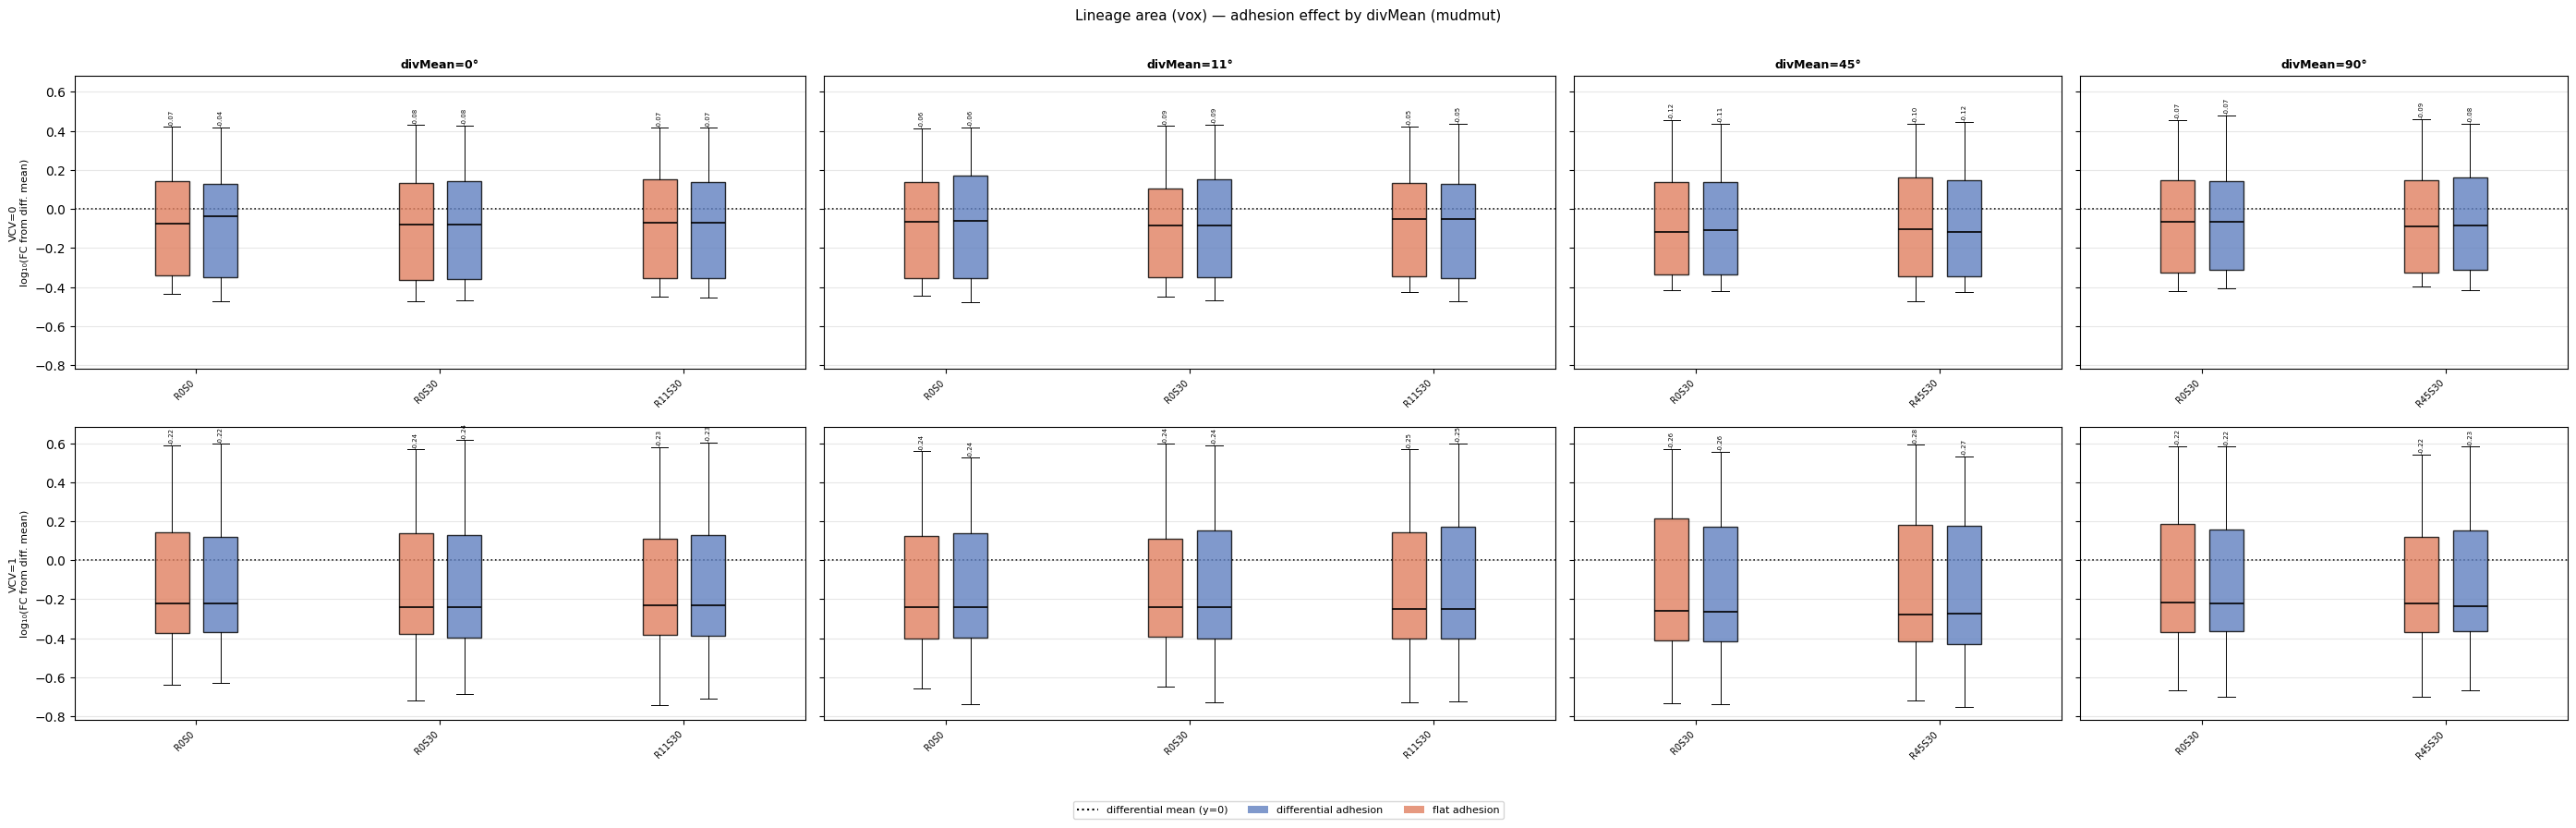

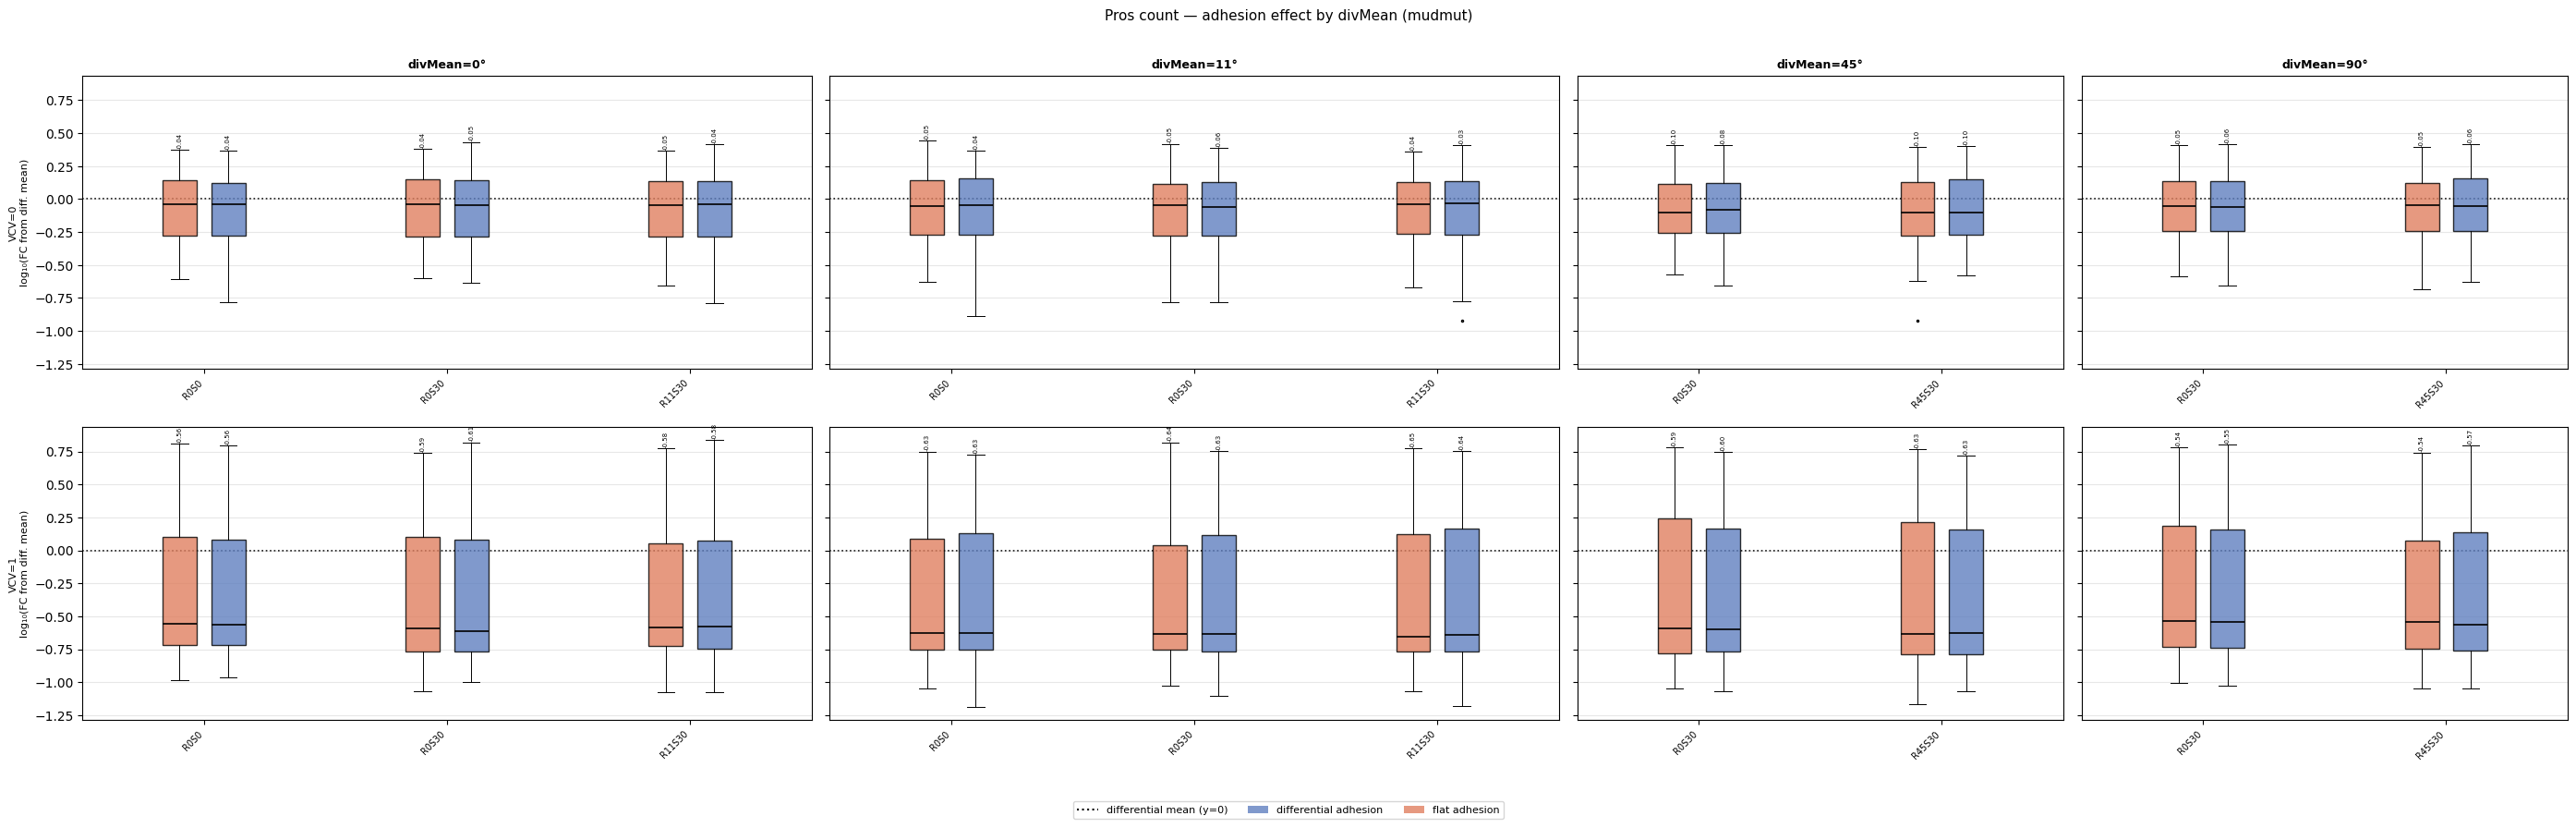

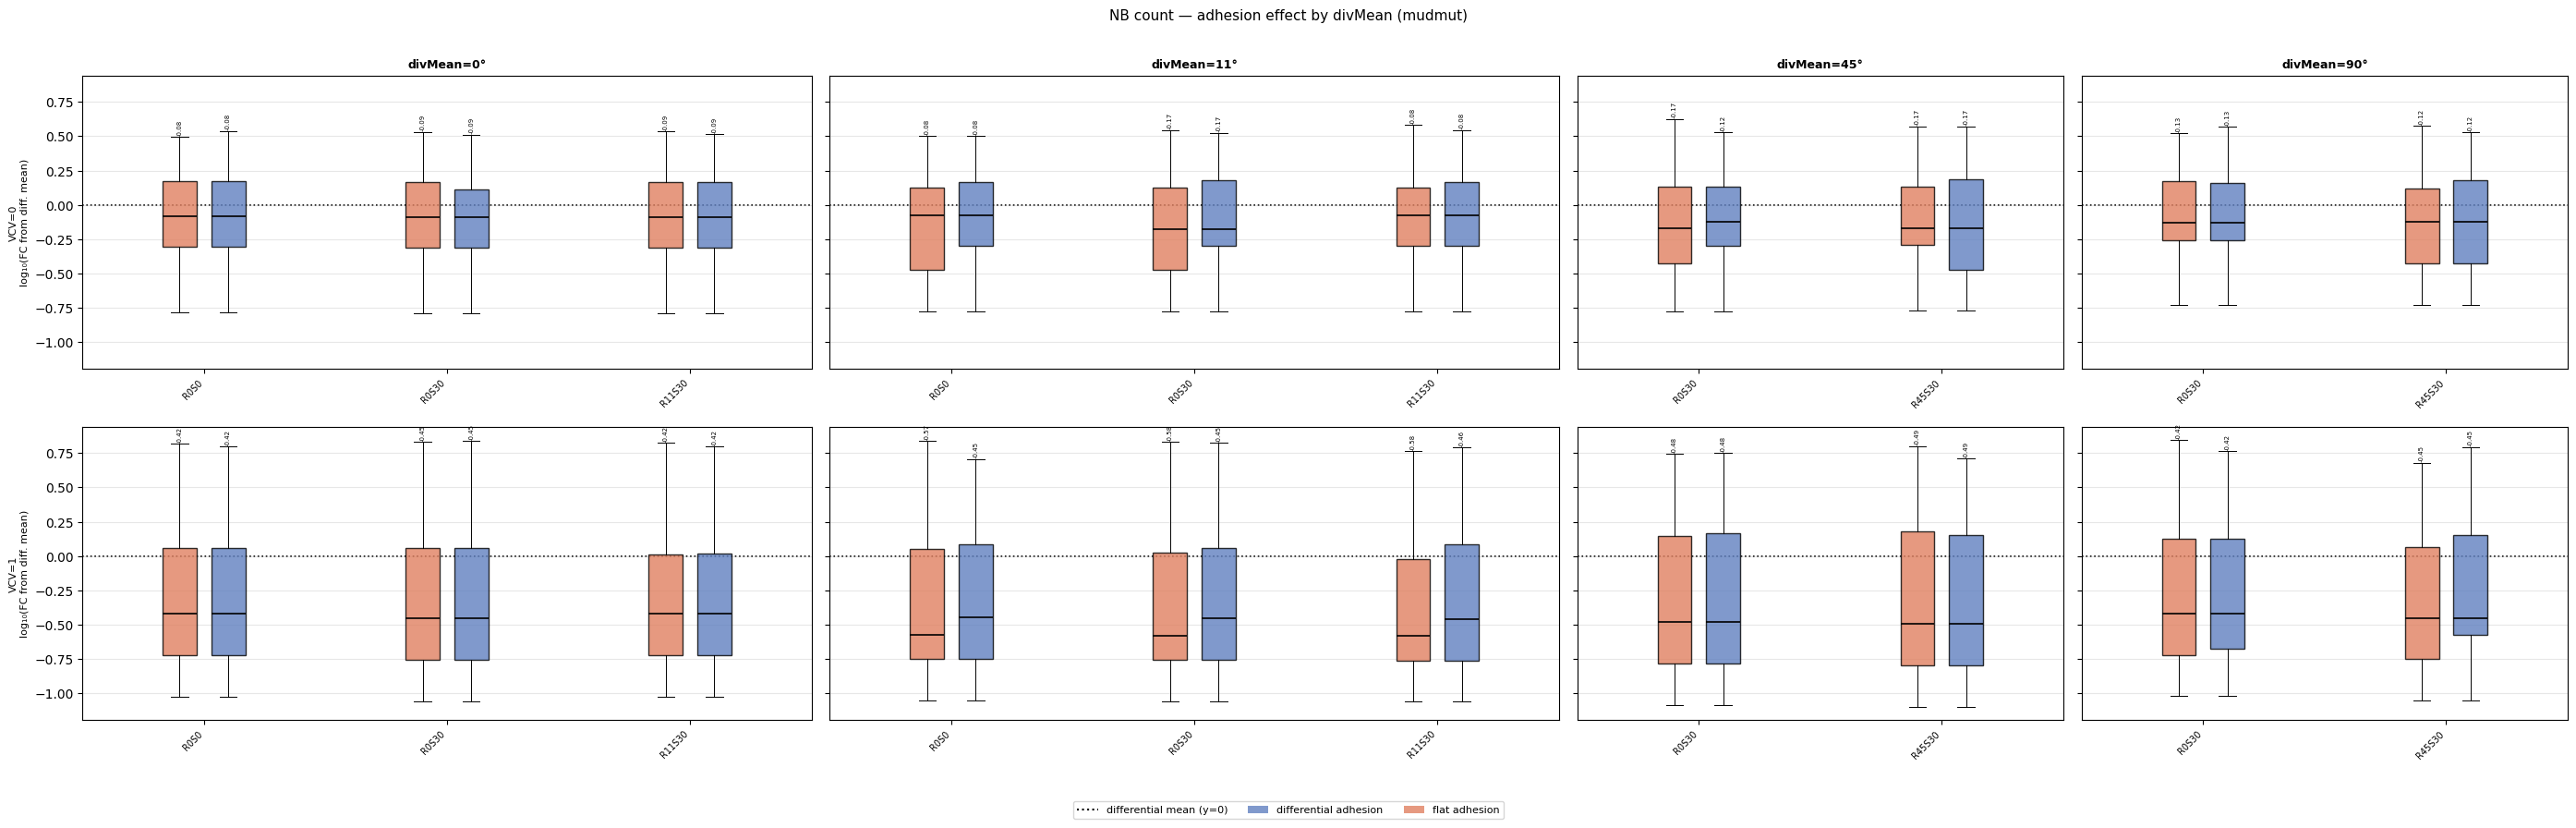

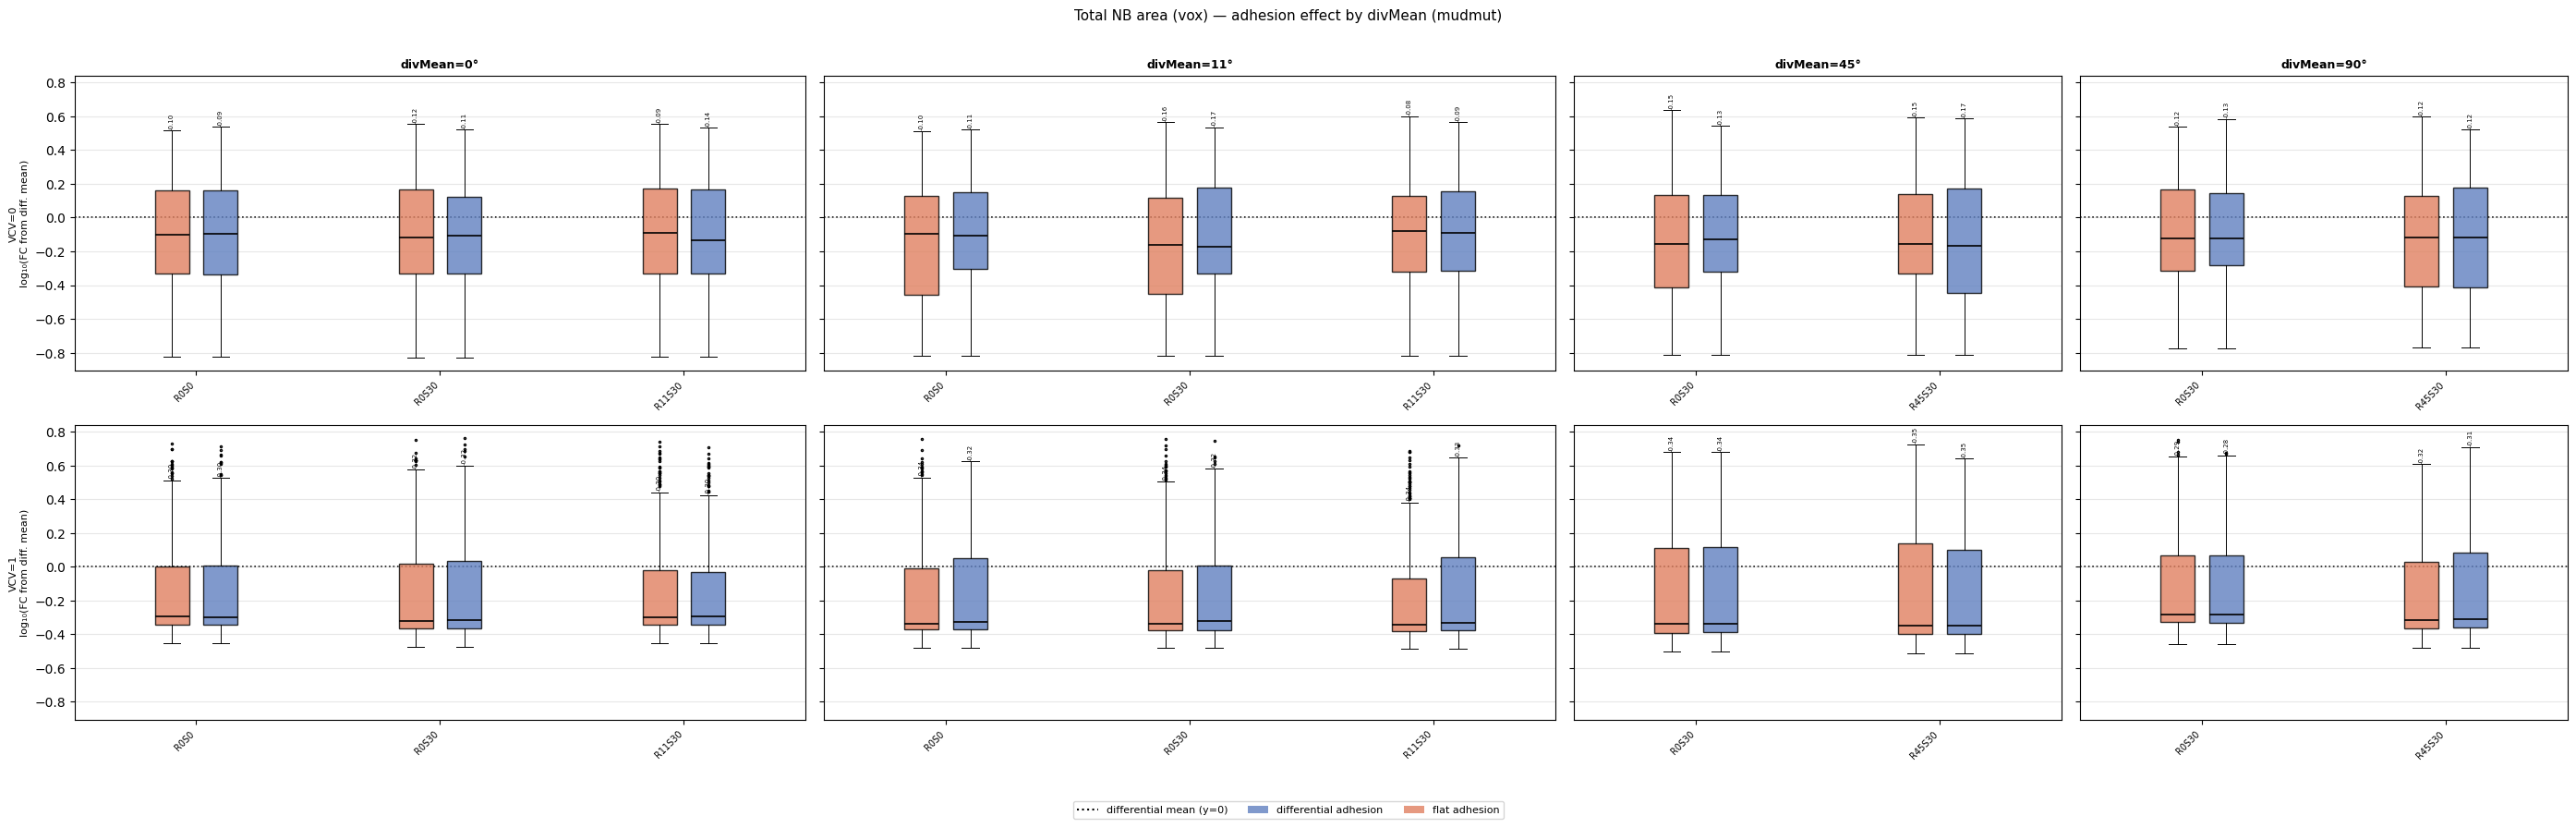

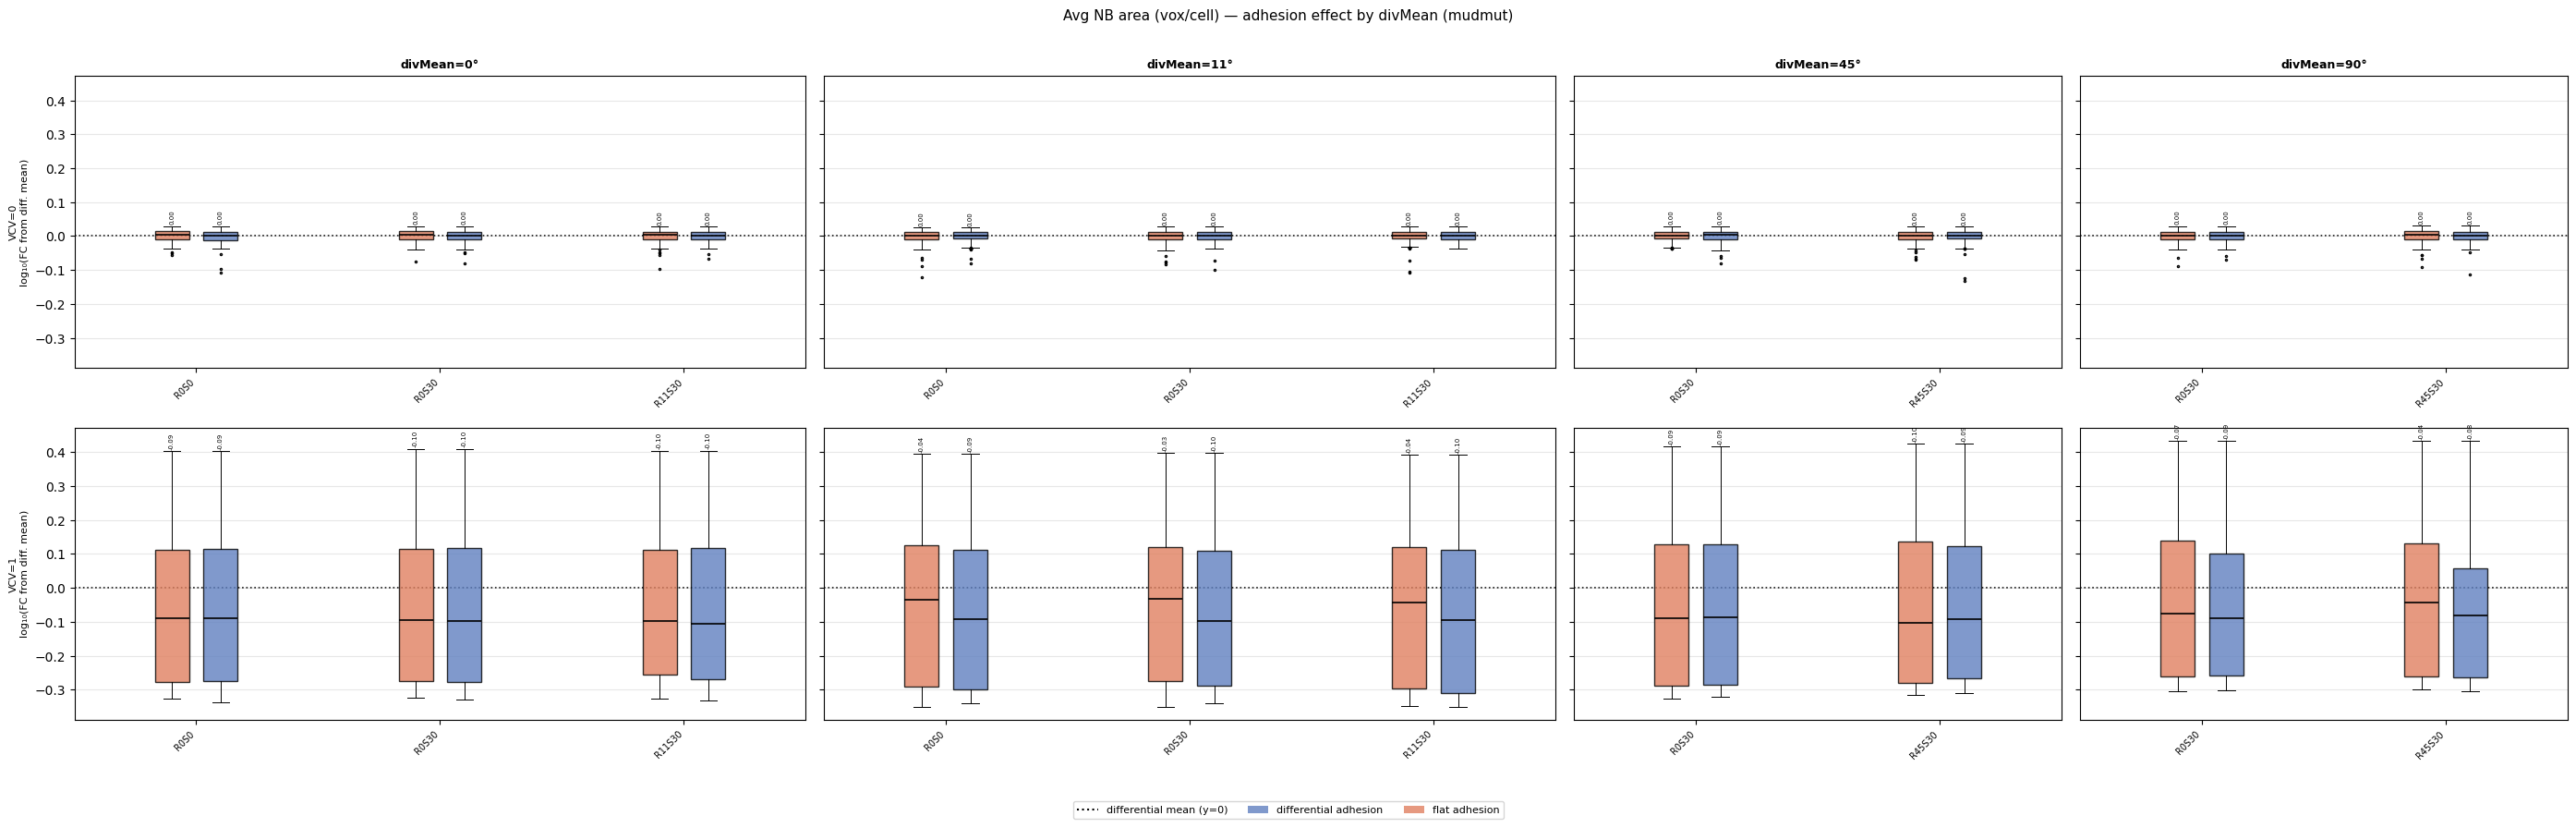

In [27]:
# Composition metrics: log FC from differential mean, faceted by divMean (columns) × VCV (rows)
ADH_COLORS = {'flat': '#e08060', 'differential': '#6080c0'}
box_w   = 0.14
offsets = np.array([-0.10, 0.10])   # flat left, differential right

vcv_modes = sorted(sim['critical_volume_mode'].dropna().unique().astype(int))
n_vcv = len(vcv_modes)

_width_ratios = [max(1, len(MM_BY_DIVMEAN.get(dm, []))) for dm in DIV_MEAN_ORDER]
_total_tags   = sum(_width_ratios)

for metric in METRICS:
    fig, axes = plt.subplots(
        n_vcv, len(DIV_MEAN_ORDER),
        figsize=(2.8 * _total_tags, 4.5 * n_vcv),
        sharey=True, squeeze=False,
        gridspec_kw={'width_ratios': _width_ratios},
    )

    for ri, vcv in enumerate(vcv_modes):
        sub = sim[
            (sim['genotype'] == 'mudmut') &
            (sim['critical_volume_mode'] == vcv)
        ].dropna(subset=[metric])

        for ci, dm in enumerate(DIV_MEAN_ORDER):
            ax = axes[ri, ci]
            ax.axhline(0, color='black', linestyle=':', linewidth=1.2, zorder=1)

            dm_pairs = MM_BY_DIVMEAN.get(dm, [])
            n = len(dm_pairs)

            for ti, p in enumerate(dm_pairs):
                tag = p['tag']
                ref_mean = sub[(sub['tag'] == tag) & (sub['adhesion'] == 'differential')][metric].mean()
                if np.isnan(ref_mean) or ref_mean == 0:
                    continue

                for ai, adh in enumerate(['flat', 'differential']):
                    if adh == 'flat' and p['noadhesion'] is None:
                        continue
                    runs = sub[(sub['tag'] == tag) & (sub['adhesion'] == adh)][metric].dropna()
                    if runs.empty:
                        continue
                    lfc = np.log10(runs / ref_mean)
                    x   = ti + offsets[ai]
                    bp  = ax.boxplot(
                        [lfc], positions=[x], widths=box_w,
                        patch_artist=True,
                        medianprops={'color': 'black', 'linewidth': 1.2},
                        whiskerprops={'linewidth': 0.7},
                        capprops={'linewidth': 0.7},
                        flierprops={'marker': 'o', 'markersize': 1.5, 'linestyle': 'none'},
                        manage_ticks=False, zorder=2,
                    )
                    bp['boxes'][0].set_facecolor(ADH_COLORS[adh])
                    bp['boxes'][0].set_alpha(0.8)
                    med       = float(np.median(lfc))
                    upper_cap = bp['caps'][1].get_ydata()[0]
                    ax.text(x, upper_cap + 0.005, f'{med:.2f}',
                            ha='center', va='bottom', fontsize=5, rotation=90)

            ax.set_xlim(-0.5, n - 0.5)
            ax.set_xticks(list(range(n)))
            ax.set_xticklabels([_rot_label(p['tag']) for p in dm_pairs],
                               rotation=45, ha='right', fontsize=7)
            ax.grid(axis='y', alpha=0.3)

            if ri == 0:
                ax.set_title(f'divMean={dm}°', fontsize=9, fontweight='bold')
            if ci == 0:
                ax.set_ylabel(f'VCV={vcv}\nlog₁₀(FC from diff. mean)', fontsize=8)

    legend_handles = [
        Line2D([0], [0], color='black', linestyle=':', label='differential mean (y=0)'),
        Patch(facecolor=ADH_COLORS['differential'], alpha=0.8, label='differential adhesion'),
        Patch(facecolor=ADH_COLORS['flat'],          alpha=0.8, label='flat adhesion'),
    ]
    fig.suptitle(f'{METRIC_LABELS[metric]} — adhesion effect by divMean (mudmut)', fontsize=11)
    fig.legend(handles=legend_handles, fontsize=8, loc='lower center',
               ncol=3, bbox_to_anchor=(0.5, 0.0))
    fig.tight_layout(rect=[0, 0.06, 1, 0.97])
    fig.savefig(FIGURES_DIR / f'composition_{metric}_by_divmean.png', dpi=120, bbox_inches='tight')
    plt.show()

---
## Section 3 — Interpretation

*(Analyst notes)*

**norm_het_frac comparison (Section 1):**
- If flat adhesion >> differential adhesion → NB-NB adhesion drives segregation. ✓
- If flat adhesion ≈ differential adhesion → division geometry or another mechanism
  is responsible.

**Composition metrics (Section 2):**
- If flat adhesion changes lin_area_vox / n_dpn substantially → adhesion affects
  growth dynamics, not just spatial organisation. This would complicate the
  comparison and should be noted.
- If composition is stable → the flat-adhesion control is a clean spatial test.


---
## Section 4 — rotMean sweep at fixed divMean=0

Examines how increasing the rotation mean (0°, 11°, 45°, 90°) changes spatial mixing
and composition when the division-plane mean is held at 0°. Both adhesion conditions
are shown for each rotation condition.

**Question:** does a higher rotation mean drive more (or less) NB-progeny intermixing,
and does removing adhesion interact with that trend?

Rows = VCV mode; columns = metric. X-axis = rotation condition tags (R0S0, R0S30, R11S30,
R45S30, R90S30). Note that R0S0 (no spread) and R0S30 (some spread around 0°) both have
rotMean=0 but differ in stochasticity.

In [ ]:
# ── Section 4: rotMean sweep at fixed divMean=0 ──────────────────────────
# All metrics in one multi-panel figure:
#   rows = VCV mode
#   columns = metric (norm_het_frac, exposed_frac, then composition metrics)
# X-axis = rotation condition label (R0S0, R0S30, R11S30, R45S30, R90S30)
# Differential adhesion vs flat adhesion shown side-by-side per condition.

ADH_COLORS = {'flat': '#e08060', 'differential': '#6080c0'}
box_w   = 0.14
offsets = np.array([-0.10, 0.10])   # flat left, differential right

D0_PAIRS = MM_BY_DIVMEAN[0]   # the 5 divMean=0 condition pairs
D0_TAGS  = [p['tag'] for p in D0_PAIRS]
D0_XLABELS = [_rot_label(t) for t in D0_TAGS]
positions  = list(range(len(D0_PAIRS)))

vcv_modes = sorted(het_df['critical_volume_mode'].dropna().unique().astype(int))
n_vcv = len(vcv_modes)

ALL_METRICS = ['norm_het_frac', 'exposed_frac'] + METRICS
METRIC_LABELS_EXT = {
    **METRIC_LABELS,
    'norm_het_frac': 'norm_het_frac',
    'exposed_frac':  'NB exposed fraction',
}
n_metrics = len(ALL_METRICS)

fig, axes = plt.subplots(
    n_vcv, n_metrics,
    figsize=(3.5 * n_metrics, 4.5 * n_vcv),
    squeeze=False,
)

for ri, vcv in enumerate(vcv_modes):
    for ci, metric in enumerate(ALL_METRICS):
        ax = axes[ri, ci]

        if metric in ('norm_het_frac',):
            df_src = het_df
            ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, zorder=1)
        elif metric in ('exposed_frac',):
            df_src = nbexp_df
            ax.set_ylim(0, 1)
        else:
            df_src = sim

        sub = df_src[
            (df_src['genotype'] == 'mudmut') &
            (df_src['critical_volume_mode'] == vcv) &
            (df_src['div_mean'] == 0)
        ].dropna(subset=[metric])

        for ti, p in enumerate(D0_PAIRS):
            tag = p['tag']
            for ai, adh in enumerate(['flat', 'differential']):
                runs = sub[(sub['tag'] == tag) & (sub['adhesion'] == adh)][metric].dropna()
                if runs.empty:
                    continue
                x  = ti + offsets[ai]
                bp = ax.boxplot(
                    [runs], positions=[x], widths=box_w,
                    patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 1.2},
                    whiskerprops={'linewidth': 0.7},
                    capprops={'linewidth': 0.7},
                    flierprops={'marker': 'o', 'markersize': 1.5, 'linestyle': 'none'},
                    manage_ticks=False, zorder=2,
                )
                bp['boxes'][0].set_facecolor(ADH_COLORS[adh])
                bp['boxes'][0].set_alpha(0.8)
                med       = float(np.median(runs))
                upper_cap = bp['caps'][1].get_ydata()[0]
                ax.text(x, upper_cap + (0.005 if metric != 'exposed_frac' else 0.01),
                        f'{med:.3f}', ha='center', va='bottom', fontsize=5, rotation=90)

        ax.set_xlim(-0.5, len(D0_PAIRS) - 0.5)
        ax.set_xticks(positions)
        ax.set_xticklabels(D0_XLABELS, rotation=45, ha='right', fontsize=7)
        ax.grid(axis='y', alpha=0.3)

        if ri == 0:
            ax.set_title(METRIC_LABELS_EXT.get(metric, metric), fontsize=9, fontweight='bold')
        if ci == 0:
            ax.set_ylabel(f'VCV={vcv}', fontsize=8)

legend_handles = [
    Line2D([0], [0], color='gray', linestyle='--', label='random mixing (norm_het_frac=1)'),
    Patch(facecolor=ADH_COLORS['differential'], alpha=0.8, label='differential adhesion'),
    Patch(facecolor=ADH_COLORS['flat'],          alpha=0.8, label='flat adhesion'),
]
fig.suptitle('rotMean sweep at divMean=0 — all metrics, differential vs flat adhesion',
             fontsize=11)
fig.legend(handles=legend_handles, fontsize=8, loc='lower center',
           ncol=3, bbox_to_anchor=(0.5, 0.0))
fig.tight_layout(rect=[0, 0.05, 1, 0.97])
fig.savefig(FIGURES_DIR / 'rotmean_sweep_divmean0_all_metrics.png',
            dpi=120, bbox_inches='tight')
plt.show()

---
## Section 5 — NB Cohesion in Constrained Colonies

Tests the claim: **differential adhesion does not affect NB clustering in sufficiently
constrained NB colonies**.

Scope: `divMean0Stdev26_rotMean0Stdev30` (differential vs flat), **VCV=1 mudmut only**,
VOL-ABM (sim43) / NB-PDE (sim44) / VOL-PDE (sim45).

**New metric — `nb_cohesion_frac`:**

    nb_cohesion_frac = NB–NB edges / (NB–NB + NB–empty + NB–progeny edges)

All 4-connected pixel edges that touch at least one NB pixel are counted; the fraction
that are NB–NB quantifies how tightly the NB region is internally connected.
High = compact cluster; low = dispersed.

Shown alongside `norm_het_frac` and `exposed_frac` for the same slice so all three
angles (mixing, boundary exposure, internal cohesion) can be read together.

In [ ]:
def nb_cohesion_fraction(geo):
    """NB–NB pixel edges / all pixel edges touching at least one NB pixel."""
    nb    = geo[..., 0] > 0
    nonnb = geo[..., 1] > 0
    emp   = ~(nb | nonnb)

    n_nb_nb = (
        int((nb[:, :-1] & nb[:, 1:]).sum()) +
        int((nb[:-1, :] & nb[1:, :]).sum())
    )
    n_exposed = n_contact = 0
    for nb_edge, emp_side, nonnb_side in [
        (nb[:, :-1] & ~nb[:, 1:],  emp[:, 1:],  nonnb[:, 1:]),
        (nb[:, 1:]  & ~nb[:, :-1], emp[:, :-1], nonnb[:, :-1]),
        (nb[:-1, :] & ~nb[1:, :],  emp[1:, :],  nonnb[1:, :]),
        (nb[1:, :]  & ~nb[:-1, :], emp[:-1, :], nonnb[:-1, :]),
    ]:
        n_exposed += int((nb_edge & emp_side).sum())
        n_contact += int((nb_edge & nonnb_side).sum())

    total = n_nb_nb + n_exposed + n_contact
    return n_nb_nb / total if total > 0 else np.nan


_TARGET_BASE = 'mudmut_divMean0Stdev26_rotMean0Stdev30'
_TARGET_FLAT = 'mudmut_divMean0Stdev26_rotMean0Stdev30_noadhesion'
_TARGET_SIMS = ['sim43', 'sim44', 'sim45']   # VOL-ABM, NB-PDE, VOL-PDE, VCV=1

_COH_CSV = PROC_DIR / 'nb_cohesion_D0S26_R0S30.csv'

if _COH_CSV.exists():
    coh_df = pd.read_csv(_COH_CSV)
    print(f'Loaded cached {_COH_CSV.name} ({len(coh_df)} rows)')
else:
    sub_idx = run_idx[
        run_idx['condition'].isin([_TARGET_BASE, _TARGET_FLAT]) &
        run_idx['sim_id'].isin(_TARGET_SIMS)
    ]
    records = []
    for npz_path_str, group in sub_idx.groupby('npz_path'):
        with np.load(REPO_ROOT / npz_path_str) as _d:
            _geo_all = _d['geo']
        for _, row in group.iterrows():
            records.append({
                'condition':        row['condition'],
                'sim_id':           row['sim_id'],
                'run_id':           row['run_id'],
                'nb_cohesion_frac': nb_cohesion_fraction(_geo_all[int(row['npz_row'])]),
            })
    coh_df = pd.DataFrame(records)
    _meta = sim[['condition', 'sim_id', 'regulatory_dynamic',
                  'critical_volume_mode', 'adhesion']].drop_duplicates()
    coh_df = coh_df.merge(_meta, on=['condition', 'sim_id'], how='left')
    coh_df.to_csv(_COH_CSV, index=False)
    print(f'Computed and saved {_COH_CSV.name} ({len(coh_df)} rows)')

print()
print(coh_df.groupby(['sim_id', 'adhesion'])['nb_cohesion_frac']
      .agg(['mean', 'median']).round(4).to_string())

In [ ]:
# ── Section 5 chart ───────────────────────────────────────────────────────
# 3 rows (metrics) × 3 columns (regulatory dynamics)
# Each panel: differential vs flat, for D0S26_R0S30, VCV=1

_REG_DYNS = ['VOL-ABM', 'NB-PDE', 'VOL-PDE']
ADH_COLORS = {'flat': '#e08060', 'differential': '#6080c0'}

# Pull the target slice from already-computed DataFrames
_slice_het = het_df[
    (het_df['condition'].isin([_TARGET_BASE, _TARGET_FLAT])) &
    (het_df['critical_volume_mode'] == 1) &
    (het_df['regulatory_dynamic'].isin(_REG_DYNS))
][['condition', 'sim_id', 'run_id', 'adhesion', 'regulatory_dynamic', 'norm_het_frac']].copy()

_slice_exp = nbexp_df[
    (nbexp_df['condition'].isin([_TARGET_BASE, _TARGET_FLAT])) &
    (nbexp_df['critical_volume_mode'] == 1) &
    (nbexp_df['regulatory_dynamic'].isin(_REG_DYNS))
][['condition', 'sim_id', 'run_id', 'exposed_frac']].copy()

_slice_coh = coh_df[['condition', 'sim_id', 'run_id', 'nb_cohesion_frac']].copy()

# Normalise run_id dtype to str across all three before merging
for _df in [_slice_het, _slice_exp, _slice_coh]:
    _df['run_id'] = _df['run_id'].astype(str)

_combined = (
    _slice_het
    .merge(_slice_exp, on=['condition', 'sim_id', 'run_id'], how='outer')
    .merge(_slice_coh,  on=['condition', 'sim_id', 'run_id'], how='outer')
)

_PLOT_METRICS = ['norm_het_frac', 'exposed_frac', 'nb_cohesion_frac']
_YLABELS = {
    'norm_het_frac':    'norm_het_frac',
    'exposed_frac':     'NB exposed fraction',
    'nb_cohesion_frac': 'NB cohesion fraction\n(NB–NB / all NB edges)',
}

fig, axes = plt.subplots(
    len(_PLOT_METRICS), len(_REG_DYNS),
    figsize=(4.5 * len(_REG_DYNS), 3.5 * len(_PLOT_METRICS)),
    squeeze=False,
)

for ri, metric in enumerate(_PLOT_METRICS):
    for ci, reg_dyn in enumerate(_REG_DYNS):
        ax = axes[ri, ci]
        panel = _combined[_combined['regulatory_dynamic'] == reg_dyn].dropna(subset=[metric])

        for ai, adh in enumerate(['flat', 'differential']):
            runs = panel[panel['adhesion'] == adh][metric].dropna()
            if runs.empty:
                continue
            bp = ax.boxplot(
                [runs], positions=[ai], widths=0.4,
                patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 1.5},
                whiskerprops={'linewidth': 0.8},
                capprops={'linewidth': 0.8},
                flierprops={'marker': 'o', 'markersize': 2, 'linestyle': 'none'},
                manage_ticks=False, zorder=2,
            )
            bp['boxes'][0].set_facecolor(ADH_COLORS[adh])
            bp['boxes'][0].set_alpha(0.8)
            med = float(np.median(runs))
            ax.text(ai, bp['caps'][1].get_ydata()[0] + 0.005,
                    f'{med:.3f}', ha='center', va='bottom', fontsize=8)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(['flat', 'differential'], fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        ax.set_xlim(-0.6, 1.6)

        if ri == 0:
            ax.set_title(reg_dyn, fontsize=10, fontweight='bold')
        if ci == 0:
            ax.set_ylabel(_YLABELS[metric], fontsize=9)

legend_handles = [
    Patch(facecolor=ADH_COLORS['differential'], alpha=0.8, label='differential adhesion'),
    Patch(facecolor=ADH_COLORS['flat'],          alpha=0.8, label='flat adhesion'),
]
fig.suptitle(
    'D0S26_R0S30, VCV=1 — NB clustering metrics: differential vs flat adhesion\n'
    'mudmut · VOL-ABM · NB-PDE · VOL-PDE',
    fontsize=11,
)
fig.legend(handles=legend_handles, fontsize=9, loc='lower center',
           ncol=2, bbox_to_anchor=(0.5, 0.0))
fig.tight_layout(rect=[0, 0.04, 1, 0.96])
fig.savefig(FIGURES_DIR / 'nb_cohesion_constrained_D0S26_R0S30.png',
            dpi=120, bbox_inches='tight')
plt.show()